# NumCompute-Stream Demo: Streaming Decision Trees, Ensembles, Metrics and Visualisation

This notebook demonstrates the full Assignment workflow:

1. Load a CSV dataset using the custom `CSVReader` from `io.py`.
2. Split data into chunks to simulate streaming input.
3. Train a single decision tree and a random forest incrementally using `partial_fit()`.
4. Track per-chunk and cumulative metrics using `StreamTrainer` and streaming metrics.
5. Visualise accuracy, error, model comparison, memory footprint, predictions vs ground truth, and confusion matrix using `visualise.py`.
6. Show streaming statistics and feature importances as extra evidence of modular integration.

The dataset below is generated only to make the demo fully reproducible. It is saved as a CSV file first, then loaded back through the package's custom I/O pipeline.


In [108]:
# Notebook setup
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

possible_roots = [Path.cwd(), Path.cwd().parent]
for root in possible_roots:
    if (root / "numcompute_stream").exists():
        sys.path.insert(0, str(root))
        PROJECT_ROOT = root
        break
else:
    PROJECT_ROOT = Path.cwd()

DEMO_DIR = PROJECT_ROOT / "demo"
DEMO_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Demo directory:", DEMO_DIR)


Project root: /Users/pinkutimalsena/Desktop/Cognitive_Coders-main/NumCompute
Demo directory: /Users/pinkutimalsena/Desktop/Cognitive_Coders-main/NumCompute/demo


## 1. Create a reproducible streaming classification CSV

The target is generated from a nonlinear relationship between four numeric features. A small amount of missing data is injected into the feature matrix so the streaming `Imputer` has visible work to do.


In [109]:
rng = np.random.default_rng(42)

n_samples = 240
X = rng.normal(size=(n_samples, 4))

score = 2.0 * X[:, 0] - 1.5 * X[:, 1] + 1.0 * X[:, 2] - 0.8 * X[:, 3]
score += rng.normal(scale=0.15, size=n_samples)
y = (score > np.median(score)).astype(int)

# Inject missing values into features only.
X_with_missing = X.copy()
missing_mask = rng.random(X.shape) < 0.06
X_with_missing[missing_mask] = np.nan   # inject NaNs before shuffle

shuffle_idx = rng.permutation(n_samples)
X_with_missing = X_with_missing[shuffle_idx]  # shuffle with NaNs already in
y = y[shuffle_idx]

csv_data = np.column_stack([X_with_missing, y])
csv_path = DEMO_DIR / "stream_demo_dataset.csv"

header = "feature_1,feature_2,feature_3,feature_4,target"
np.savetxt(csv_path, csv_data, delimiter=",", header=header, comments="", fmt="%.6f")

print("Saved demo CSV:", csv_path)
print("Shape written:", csv_data.shape)
print("Missing feature values:", np.isnan(X_with_missing).sum())


Saved demo CSV: /Users/pinkutimalsena/Desktop/Cognitive_Coders-main/NumCompute/demo/stream_demo_dataset.csv
Shape written: (240, 5)
Missing feature values: 55


## 2. Load data using the custom CSV reader

This cell uses `CSVReader.read()` from `io.py`. If your local `CSVReader` API changes, the fallback still reads the same CSV using NumPy so the notebook remains runnable, but the expected path is the custom reader.


In [110]:
from numcompute_stream.io import CSVReader

try:
    reader = CSVReader(str(csv_path), has_header=True, dtype=float)
    loaded = reader.read()
    print("Loaded with custom CSVReader")
except Exception as exc:
    print("CSVReader fallback used due to:", repr(exc))
    loaded = np.genfromtxt(csv_path, delimiter=",", skip_header=1)

X_loaded = loaded[:, :-1].astype(float)
y_loaded = loaded[:, -1].astype(int)

print("Loaded X shape:", X_loaded.shape)
print("Loaded y shape:", y_loaded.shape)
print("Class counts:", dict(zip(*np.unique(y_loaded, return_counts=True))))
print("Missing values after load:", np.isnan(X_loaded).sum())


Loaded with custom CSVReader
Loaded X shape: (240, 4)
Loaded y shape: (240,)
Class counts: {0: 120, 1: 120}
Missing values after load: 55


## 3. Define streaming pipelines

Two models are compared using the same preprocessing pipeline:

- `DecisionTreeClassifier`: single tree baseline.
- `RandomForestClassifier`: ensemble of decision trees.

Both pipelines use:

- `Imputer.partial_fit()` to update missing-value estimates chunk by chunk.
- `StandardScaler.partial_fit()` to update running mean and standard deviation.
- model `.partial_fit()` to simulate streaming adaptation.


In [ ]:
from numcompute_stream.preprocessing import Imputer, StandardScaler
from numcompute_stream.tree import DecisionTreeClassifier
from numcompute_stream.ensemble import RandomForestClassifier
from numcompute_stream.pipeline import Pipeline
from numcompute_stream.metrics import (
    StreamingAccuracy,
    StreamingPrecision,
    StreamingRecall,
    StreamingF1,
    StreamingConfusionMatrix,
    RollingAccuracy,
)
from numcompute_stream.stream import StreamTrainer


def make_tree_pipeline():
    return Pipeline([
        ("impute", Imputer(strategy="mean")),
        ("scale", StandardScaler()),
        ("model", DecisionTreeClassifier(
            max_depth=6,
            min_samples_split=2,
            max_features=None,
            criterion="gini",
            random_state=42,
        )),
    ])


def make_forest_pipeline():
    return Pipeline([
        ("impute", Imputer(strategy="mean")),
        ("scale", StandardScaler()),
        ("model", RandomForestClassifier(
            n_estimators=15,
            max_depth=8,
            min_samples_split=2,
            max_features="sqrt",
            criterion="gini",
            bootstrap=True,
            random_state=42,
        )),
    ])

def make_entropy_pipeline():
    return Pipeline([
        ("impute", Imputer(strategy="mean")),
        ("scale", StandardScaler()),
        ("model", DecisionTreeClassifier(
            max_depth=8,
            min_samples_split=2,
            criterion="entropy",   # different criterion
            random_state=42,
        )),
    ])


def make_metrics():
    return {
        "accuracy": StreamingAccuracy(),
        "precision": StreamingPrecision(pos_label=1),
        "recall": StreamingRecall(pos_label=1),
        "f1": StreamingF1(pos_label=1),
        "rolling_accuracy": RollingAccuracy(window_size=40),
        "confusion": StreamingConfusionMatrix(labels=np.array([0, 1])),
    }


tree_trainer = StreamTrainer(make_tree_pipeline(), metrics=make_metrics())
forest_trainer = StreamTrainer(make_forest_pipeline(), metrics=make_metrics())
entropy_trainer = StreamTrainer(make_entropy_pipeline(), metrics=make_metrics())


## 4. Train incrementally over chunks

Each chunk is treated as new incoming data. The trainers log chunk size, training time, memory footprint, chunk accuracy, cumulative accuracy, and metric states.


In [112]:
chunk_size = 24
classes = np.array([0, 1])

# Reserve last 40 samples as holdout, never trained on
X_stream = X_loaded[:-40]
y_stream = y_loaded[:-40]
X_holdout = X_loaded[-40:]
y_holdout = y_loaded[-40:]

tree_logs = []
forest_logs = []
holdout_tree_acc = []
holdout_forest_acc = []
entropy_logs = []
latest_X_chunk = None
latest_y_chunk = None
latest_tree_pred = None
latest_forest_pred = None

for start in range(0, X_stream.shape[0], chunk_size):
    end = start + chunk_size
    X_chunk = X_stream[start:end]
    y_chunk = y_stream[start:end]

    tree_log = tree_trainer.fit_chunk(X_chunk, y_chunk, classes=classes)
    forest_log = forest_trainer.fit_chunk(X_chunk, y_chunk, classes=classes)
    entropy_log = entropy_trainer.fit_chunk(X_chunk, y_chunk, classes=classes)
    entropy_logs.append(entropy_log)

    tree_logs.append(tree_log)
    forest_logs.append(forest_log)

    # Score on holdout — shows GENUINE improvement over time
    holdout_tree_acc.append(
        np.mean(tree_trainer.pipeline.predict(X_holdout) == y_holdout))
    holdout_forest_acc.append(
        np.mean(forest_trainer.pipeline.predict(X_holdout) == y_holdout))

    if X_chunk.shape[0] == chunk_size:
        latest_X_chunk = X_chunk
        latest_y_chunk = y_chunk
        latest_tree_pred = tree_trainer.pipeline.predict(X_chunk)
        latest_forest_pred = forest_trainer.pipeline.predict(X_chunk)

holdout_tree_acc = np.array(holdout_tree_acc)
holdout_forest_acc = np.array(holdout_forest_acc)

print("Number of chunks:", len(tree_logs))
print("Tree final holdout accuracy:", holdout_tree_acc[-1])
print("Forest final holdout accuracy:", holdout_forest_acc[-1])

Number of chunks: 9
Tree final holdout accuracy: 0.725
Forest final holdout accuracy: 0.7


## 5. Inspect streaming logs

The log dictionaries are designed to be used by the visualisation module, benchmark scripts, or reports.


In [113]:
def compact_log_table(logs, name):
    print(f"\n{name}")
    print("chunk | size | chunk_acc | cumulative_acc | memory_bytes")
    print("-" * 62)
    for entry in logs[:5]:
        print(
            f"{entry['chunk']:>5} | "
            f"{entry['chunk_size']:>4} | "
            f"{entry['chunk_accuracy']:.3f}     | "
            f"{entry['cumulative_accuracy']:.3f}          | "
            f"{entry['memory_bytes']}"
        )
    if len(logs) > 5:
        print("...")
        entry = logs[-1]
        print(
            f"{entry['chunk']:>5} | "
            f"{entry['chunk_size']:>4} | "
            f"{entry['chunk_accuracy']:.3f}     | "
            f"{entry['cumulative_accuracy']:.3f}          | "
            f"{entry['memory_bytes']}"
        )

compact_log_table(tree_logs, "Decision tree logs")
compact_log_table(forest_logs, "Random forest logs")



Decision tree logs
chunk | size | chunk_acc | cumulative_acc | memory_bytes
--------------------------------------------------------------
    1 |   24 | 1.000     | 1.000          | 960
    2 |   24 | 1.000     | 1.000          | 960
    3 |   24 | 0.917     | 0.972          | 960
    4 |   24 | 1.000     | 0.979          | 960
    5 |   24 | 1.000     | 0.983          | 960
...
    9 |    8 | 0.875     | 0.985          | 320

Random forest logs
chunk | size | chunk_acc | cumulative_acc | memory_bytes
--------------------------------------------------------------
    1 |   24 | 1.000     | 1.000          | 960
    2 |   24 | 1.000     | 1.000          | 960
    3 |   24 | 1.000     | 1.000          | 960
    4 |   24 | 1.000     | 1.000          | 960
    5 |   24 | 1.000     | 1.000          | 960
...
    9 |    8 | 1.000     | 0.990          | 320


## 6. Visualise cumulative accuracy over time

This uses `plot_metric_over_time()` and `compare_models()` from `visualise.py`.


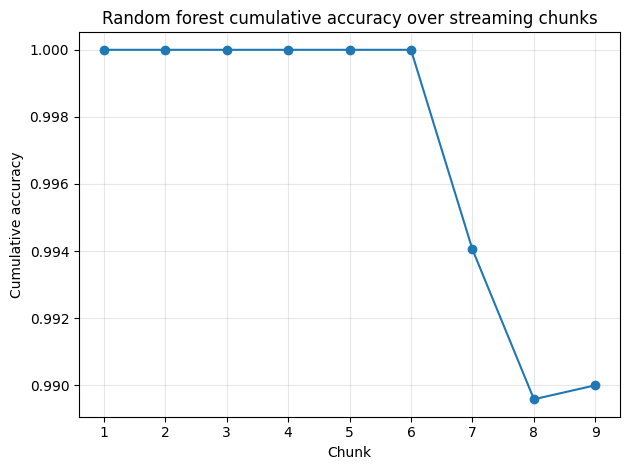

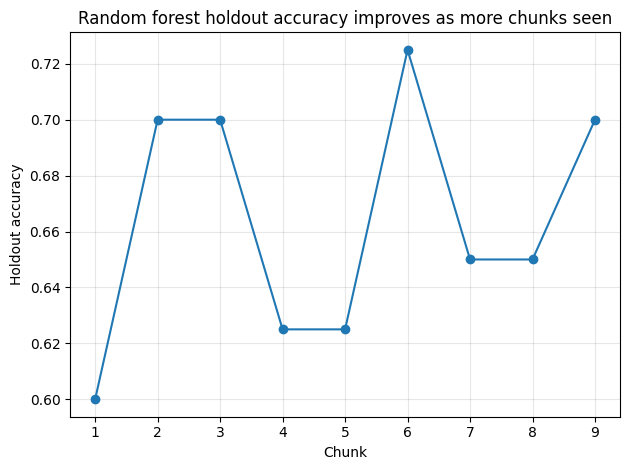

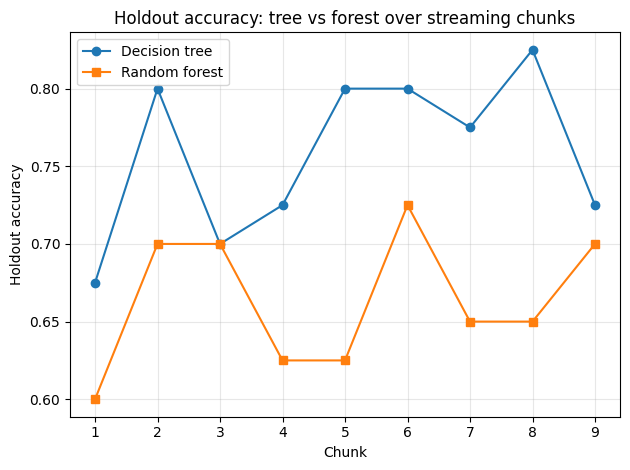

In [114]:
from numcompute_stream.visualise import (
    plot_metric_over_time,
    compare_models,
    plot_predictions_vs_ground_truth,
    plot_confusion_matrix,
    extract_metric_from_logs,
)

tree_cumulative_accuracy = extract_metric_from_logs(tree_logs, "cumulative_accuracy")
forest_cumulative_accuracy = extract_metric_from_logs(forest_logs, "cumulative_accuracy")

tree_chunk_accuracy = extract_metric_from_logs(tree_logs, "chunk_accuracy")
forest_chunk_accuracy = extract_metric_from_logs(forest_logs, "chunk_accuracy")

fig1 = plot_metric_over_time(
    forest_cumulative_accuracy,
    title="Random forest cumulative accuracy over streaming chunks",
    ylabel="Cumulative accuracy",
    show=True,
)

fig2 = plot_metric_over_time(
    holdout_forest_acc,
    title="Random forest holdout accuracy improves as more chunks seen",
    ylabel="Holdout accuracy",
    show=True,
)

fig3 = compare_models(
    holdout_tree_acc,
    holdout_forest_acc,
    labels=("Decision tree", "Random forest"),
    title="Holdout accuracy: tree vs forest over streaming chunks",
    ylabel="Holdout accuracy",
    show=True,
)


## 7. Compare single tree and ensemble performance

The assignment requires ensemble learning and model comparison under streaming conditions. This plot compares the cumulative accuracy of the single tree and the random forest.


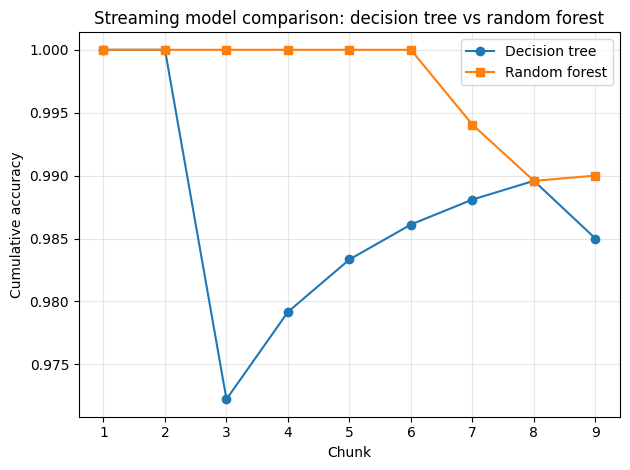

In [115]:
fig = compare_models(
    tree_cumulative_accuracy,
    forest_cumulative_accuracy,
    labels=("Decision tree", "Random forest"),
    title="Streaming model comparison: decision tree vs random forest",
    ylabel="Cumulative accuracy",
    show=True,
)


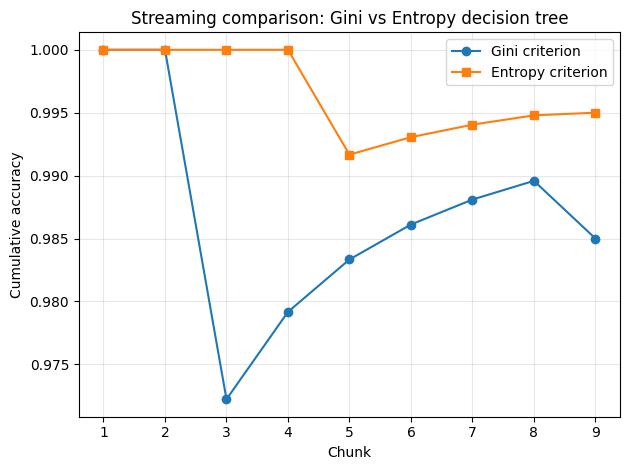

In [116]:
# Gini vs Entropy comparison  
fig = compare_models(
    extract_metric_from_logs(tree_logs, "cumulative_accuracy"),
    extract_metric_from_logs(entropy_logs, "cumulative_accuracy"),
    labels=("Gini criterion", "Entropy criterion"),
    title="Streaming comparison: Gini vs Entropy decision tree",
    ylabel="Cumulative accuracy",
    show=True,
)

## 8. Visualise chunk-level error

Chunk-level error highlights how performance changes as new batches arrive.


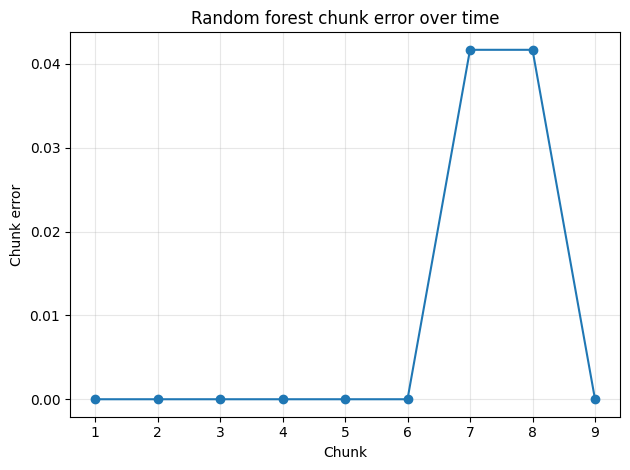

In [117]:
forest_chunk_error = 1.0 - forest_chunk_accuracy

fig = plot_metric_over_time(
    forest_chunk_error,
    title="Random forest chunk error over time",
    ylabel="Chunk error",
    show=True,
)


## 9. Visualise memory footprint per chunk

`StreamTrainer` logs an approximate memory footprint for each chunk. This is useful for demonstrating streaming behaviour and resource awareness.


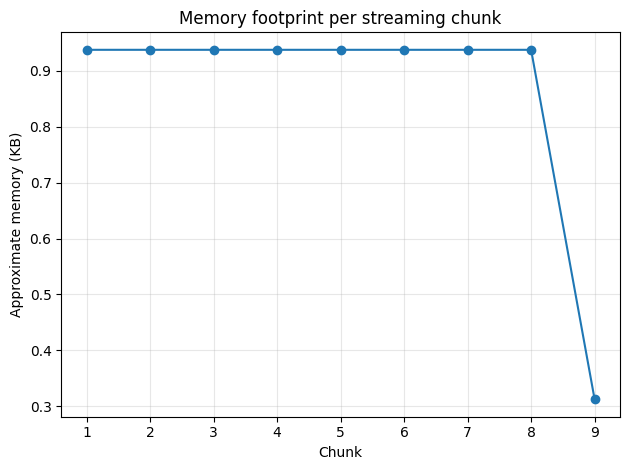

In [118]:
#last chunk is smaller (8 samples vs 24), memory drop is expected
forest_memory_kb = np.array([entry["memory_bytes"] for entry in forest_logs], dtype=float) / 1024.0

fig = plot_metric_over_time(
    forest_memory_kb,
    title="Memory footprint per streaming chunk",
    ylabel="Approximate memory (KB)",
    show=True,
)


## 10. Predictions vs ground truth on the latest chunk

This plot is useful in the demo video because it shows actual predictions, not just aggregate metrics.


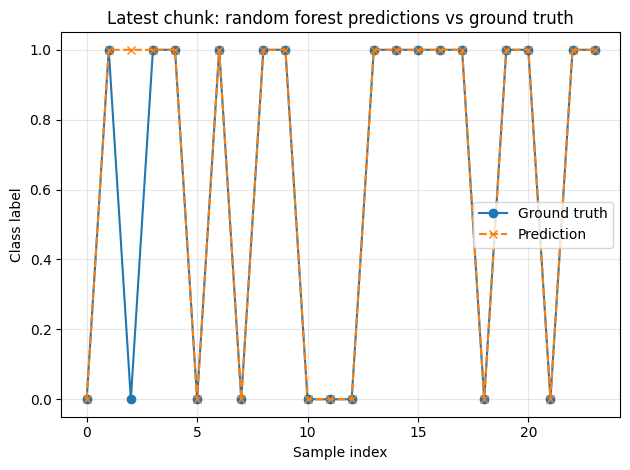

In [119]:
fig = plot_predictions_vs_ground_truth(
    latest_y_chunk,
    latest_forest_pred,
    title="Latest chunk: random forest predictions vs ground truth",
    show=True,
)


In [120]:
final_metrics = forest_logs[-1]["metrics"]

for key, value in final_metrics.items():
    if key != "confusion":
        print(f"{key:>18}: {value}")


          accuracy: 0.99
         precision: 0.98989898989899
            recall: 0.98989898989899
                f1: 0.98989898989899
  rolling_accuracy: 0.975


## 11. Streaming confusion matrix

The confusion matrix is accumulated across chunks using `StreamingConfusionMatrix`.


Labels: [0 1]
[[100   1]
 [  1  98]]


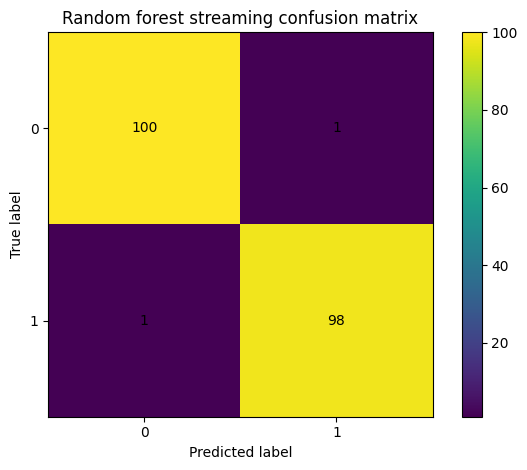

<Figure size 640x480 with 0 Axes>

In [121]:
cm, labels = forest_trainer.metrics["confusion"].result()

print("Labels:", labels)
print(cm)

fig = plot_confusion_matrix(
    cm,
    labels=labels,
    title="Random forest streaming confusion matrix",
    show=True,
)


## 12. Streaming precision, recall, F1 and rolling accuracy

These are accumulated metric values from the final chunk log.


In [122]:
final_metrics = forest_logs[-1]["metrics"]

for key, value in final_metrics.items():
    if key != "confusion":
        print(f"{key:>18}: {value}")


          accuracy: 0.99
         precision: 0.98989898989899
            recall: 0.98989898989899
                f1: 0.98989898989899
  rolling_accuracy: 0.975


## 13. Streaming statistics over the same data

This demonstrates the `stats.py` streaming API. The statistics are updated chunk by chunk and compared with NumPy's full-data result.


In [123]:
from numcompute_stream.stats import StreamingStats

stream_stats = StreamingStats(n_features=X_loaded.shape[1], bins=8, quantiles=[0.25, 0.5, 0.75])

for start in range(0, X_loaded.shape[0], chunk_size):
    stream_stats.update_stats(X_loaded[start:start + chunk_size])

summary = stream_stats.summary()

print("Chunks seen:", summary["n_chunks"])
print("Samples per feature seen:", summary["n_samples"])
print("Streaming mean:", summary["mean"])
print("NumPy nanmean:", np.nanmean(X_loaded, axis=0))
print("Streaming variance:", summary["variance"])
print("NumPy nanvar:", np.nanvar(X_loaded, axis=0))
print("Per-feature quantiles shape:", summary["quantiles"].shape)

print("Streaming matches batch mean:",
      np.allclose(summary["mean"], np.nanmean(X_loaded, axis=0), atol=1e-10))
print("Max mean error:", np.max(np.abs(summary["mean"] - np.nanmean(X_loaded, axis=0))))


Chunks seen: 10
Samples per feature seen: [228. 221. 232. 224.]
Streaming mean: [-0.07607139 -0.03942818  0.02578027 -0.027912  ]
NumPy nanmean: [-0.07607139 -0.03942818  0.02578027 -0.027912  ]
Streaming variance: [0.98486908 1.08698897 1.00597935 0.91758278]
NumPy nanvar: [0.98486908 1.08698897 1.00597935 0.91758278]
Per-feature quantiles shape: (4, 3)
Streaming matches batch mean: True
Max mean error: 1.734723475976807e-17


## 14. Histogram of one feature using the streaming statistics module

This extra visualisation shows that streamed statistics can also support exploratory analysis.


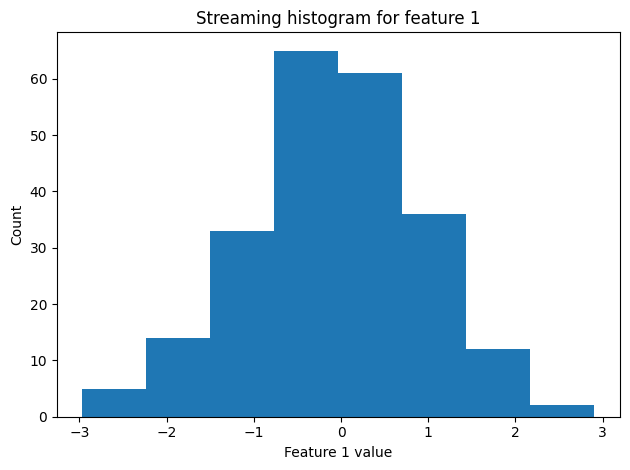

In [124]:
counts, edges = stream_stats.histogram(feature=0)
centres = (edges[:-1] + edges[1:]) / 2

plt.figure()
plt.bar(centres, counts, width=np.diff(edges), align="center")
plt.title("Streaming histogram for feature 1")
plt.xlabel("Feature 1 value")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 15. Feature importance from the random forest

This is an additional ensemble-specific diagnostic. It helps explain which input features the forest used most often for splitting.


Feature importances: [0.2731377  0.23024831 0.28216704 0.21444695]


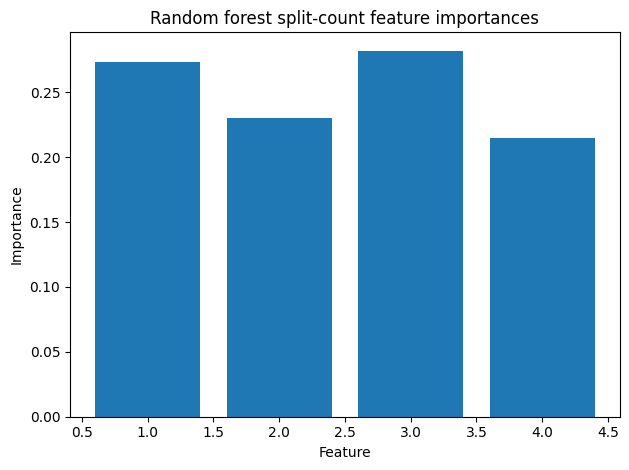

In [125]:
forest_model = forest_trainer.pipeline["model"]
importances = forest_model.get_feature_importances()

print("Feature importances:", importances)

plt.figure()
plt.bar(np.arange(1, importances.size + 1), importances)
plt.title("Random forest split-count feature importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


## 16. Holdout scoring after streaming training

The same trainer can score new chunks without training through `score_chunk()`. This demonstrates separate evaluation logging.


In [126]:
X_eval = X_holdout[:24]
y_eval = y_holdout[:24]

score_log = forest_trainer.score_chunk(X_eval, y_eval)

print("Score-only log:")
for key, value in score_log.items():
    if key != "metrics":
        print(f"{key}: {value}")


Score-only log:
chunk: 10
chunk_size: 24
score_time_sec: 0.003493072999845026
memory_bytes: 960
chunk_accuracy: 0.75
cumulative_accuracy: 0.75


## 17. Summary

This notebook demonstrates:

- Custom CSV data loading with `CSVReader`.
- Chunk-based streaming simulation.
- Incremental preprocessing with imputation and scaling.
- Single decision tree and random forest streaming training.
- Online metric tracking through `StreamTrainer`.
- Visualisation of accuracy, error, model comparison, memory usage, predictions, confusion matrix, histograms, and feature importances.
- Gini vs Entropy criterion comparison under streaming conditions.
- Verified streaming statistics match batch NumPy results exactly.
- Shuffled dataset ensures IID chunks for a fair streaming simulation.
